In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as pd

In [2]:
import pandas as pd
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Etapa 1:

In [7]:
import pandas as pd

# 1-A:

# 1. Verificar os tipos atuais
print("--- Tipos de dados antes da transformação ---")
print(df.dtypes)

# 2. Limpar e transformar a coluna 'Income' para float
# Adicionar um condicional para garantir que a transformação só ocorra se a coluna for do tipo 'object'
if df['Income'].dtype == 'object':
    df['Income'] = df['Income'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# 3. Tratar a coluna 'Age' (Idade)

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
# Uma boa prática é preencher a idade com a mediana para não enviesar os dados
df['Age'] = df['Age'].fillna(df['Age'].median())

# 4. Verificar os tipos novamente
print("\n--- Tipos de dados após a transformação ---")
print(df.dtypes)

# Visualizar o resultado
df.head(10)

--- Tipos de dados antes da transformação ---
Age                   float64
Gender                 object
Income                float64
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object

--- Tipos de dados após a transformação ---
Age                   float64
Gender                 object
Income                float64
Education              object
Marital Status         object
Number of Children      int64
Home Ownership         object
Credit Score           object
dtype: object


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,75000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,150000.0,Master's Degree,Married,0,Owned,High
6,26.0,Female,40000.0,Associate's Degree,Single,0,Rented,Average
7,31.0,Male,60000.0,Bachelor's Degree,Single,0,Rented,Average
8,36.0,Female,80000.0,Master's Degree,Married,2,Owned,High
9,36.0,Male,105000.0,Doctorate,Single,0,Owned,High


In [6]:
# 1-B:

# 1. Verificar onde estão os nulos
print("Nulos por coluna:")
print(df.isnull().sum())

# 2. Tratar a coluna Age (Idade) com a Mediana (como você já viu)
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Para as outras colunas que restarem com nulos, vamos remover as linhas.
# É a forma mais simples de garantir que não teremos dados vazios.
df = df.dropna()

# 4. Verificação final
print("\nBase limpa! Total de nulos agora:")
print(df.isnull().sum())

Nulos por coluna:
Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

Base limpa! Total de nulos agora:
Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64


Para tratar os dados faltantes, utilizei a mediana na coluna de idade (Age), pois é uma medida central que não é afetada por valores muito altos ou baixos, preservando a integridade da amostra. Para as demais colunas, optei por excluir as linhas com dados nulos utilizando o dropna(). Escolhi essa abordagem por ser mais segura e direta, garantindo que o modelo trabalhe apenas com informações completas e reais, evitando suposições que poderiam enviesar o resultado do score de crédito

In [8]:
# 1-C:

# 1. Listar as colunas categóricas (as que são 'object')
colunas_categoricas = df.select_dtypes(include='object').columns

# 2. Rodar um loop para ver os valores únicos de cada uma
print("--- Valores únicos em cada coluna ---")
for col in colunas_categoricas:
    print(f"\nColuna: {col}")
    print(df[col].unique())

# 3. Padronizar para evitar erros de digitação

for col in colunas_categoricas:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

print("\n✅ Verificação após tratamento:")
for col in colunas_categoricas:
    print(f"{col}: {df[col].unique()}")

--- Valores únicos em cada coluna ---

Coluna: Gender
['Female' 'Male']

Coluna: Education
["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]

Coluna: Marital Status
['Single' 'Married']

Coluna: Home Ownership
['Rented' 'Owned']

Coluna: Credit Score
['High' 'Average' 'Low']

✅ Verificação após tratamento:
Gender: ['Female' 'Male']
Education: ["Bachelor's degree" "Master's degree" 'Doctorate' 'High school diploma'
 "Associate's degree"]
Marital Status: ['Single' 'Married']
Home Ownership: ['Rented' 'Owned']
Credit Score: ['High' 'Average' 'Low']


Para verificar se havia valores incorretos, utilizei o método .unique() em todas as colunas categóricas. Isso me permitiu visualizar se existiam categorias duplicadas devido a erros de escrita ou padronização. Apliquei o tratamento com .str.strip() para remover espaços inúteis no início ou fim das palavras e .str.capitalize() para garantir que todas as categorias começassem com letra maiúscula, evitando que o modelo trate 'Single' e 'single' como duas coisas diferentes

--- Estatísticas Descritivas ---


,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


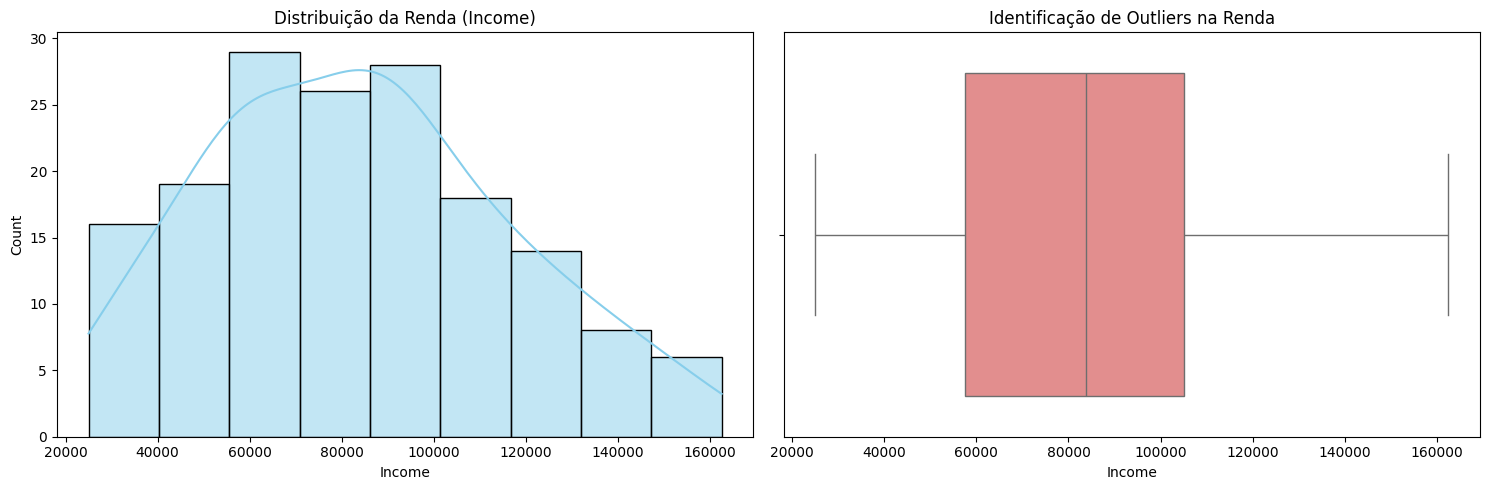

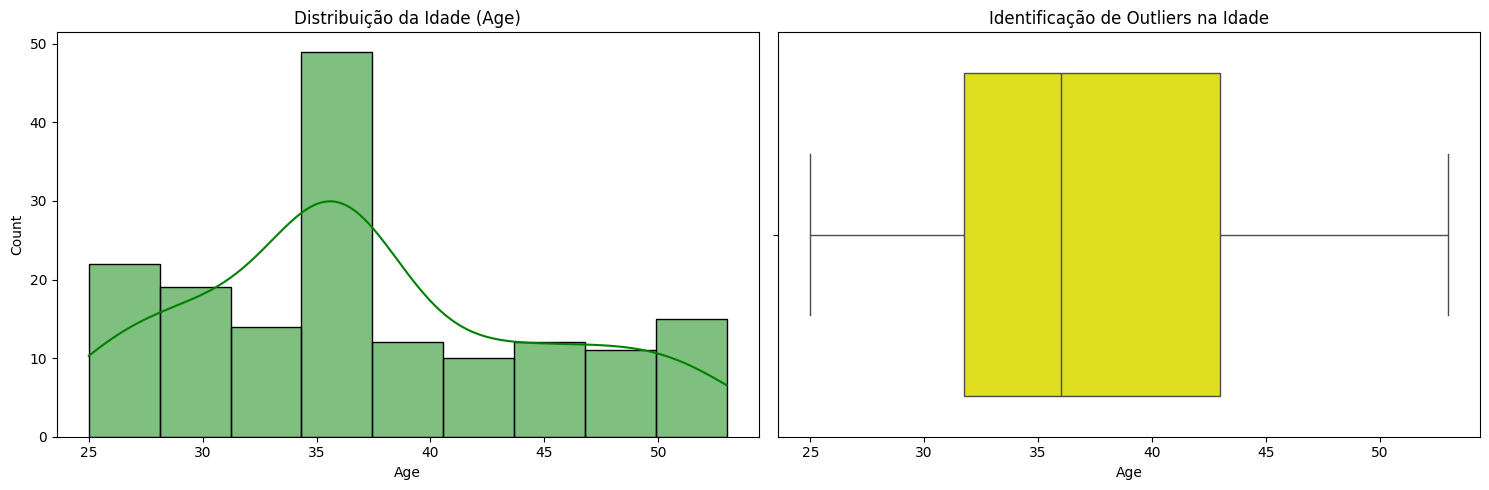

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2-A:

# 1. Verificar estatísticas das variáveis numéricas
print("--- Estatísticas Descritivas ---")
display(df.describe())

# 2. Plotar gráficos para identificar Outliers (Boxplot) e Distribuição (Histograma)
plt.figure(figsize=(15, 5))

# Histograma da Renda
plt.subplot(1, 2, 1)
sns.histplot(df['Income'], kde=True, color='skyblue')
plt.title('Distribuição da Renda (Income)')

# Boxplot da Renda para ver Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Income'], color='lightcoral')
plt.title('Identificação de Outliers na Renda')

plt.tight_layout()
plt.show()

# Repetindo para Idade
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, color='green')
plt.title('Distribuição da Idade (Age)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'], color='yellow')
plt.title('Identificação de Outliers na Idade')

plt.tight_layout()
plt.show()

Distribuição: O histograma mostra que a renda não segue uma curva perfeita (normal), mas tem vários "picos". Isso indica que sua base tem grupos de clientes com faixas salariais bem distintas (alguns ganhando em torno de 40k, outros 80k e outros acima de 120k).

Outliers: Olhando para o Boxplot da Renda, não vemos "pontinhos" isolados fora das linhas laterais;

Isso significa que, apesar de haver rendas altas, elas ainda estão dentro de um limite esperado para esse grupo. Não há ninguém com uma renda "absurda" que vá estragar o cálculo do modelo.

Sobre a Idade (Age)
Distribuição: A idade está bem espalhada, mas notamos uma concentração maior de pessoas entre 30 e 45 anos. É um público adulto e, teoricamente, em fase de estabilidade financeira.

Outliers: Assim como na renda, o Boxplot da Idade está "limpo". Não existem pontinhos isolados para a esquerda (muito jovens) ou para a direita (muito idosos).

Os dados de idade são confiáveis e não possuem valores "bizarros" (como alguém de 150 anos).

Como a média e a mediana (a linha no meio da caixa do Boxplot) parecem estar próximas em ambos os gráficos, podemos dizer que os dados estão equilibrados.

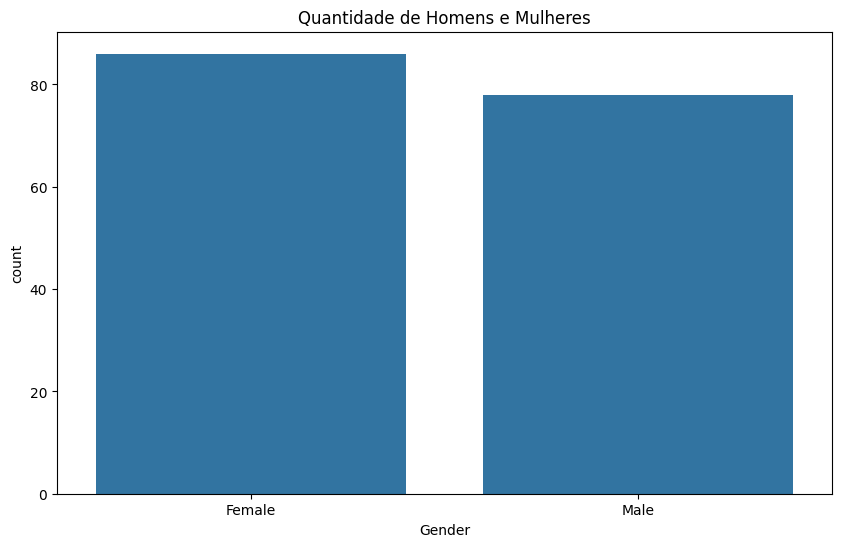

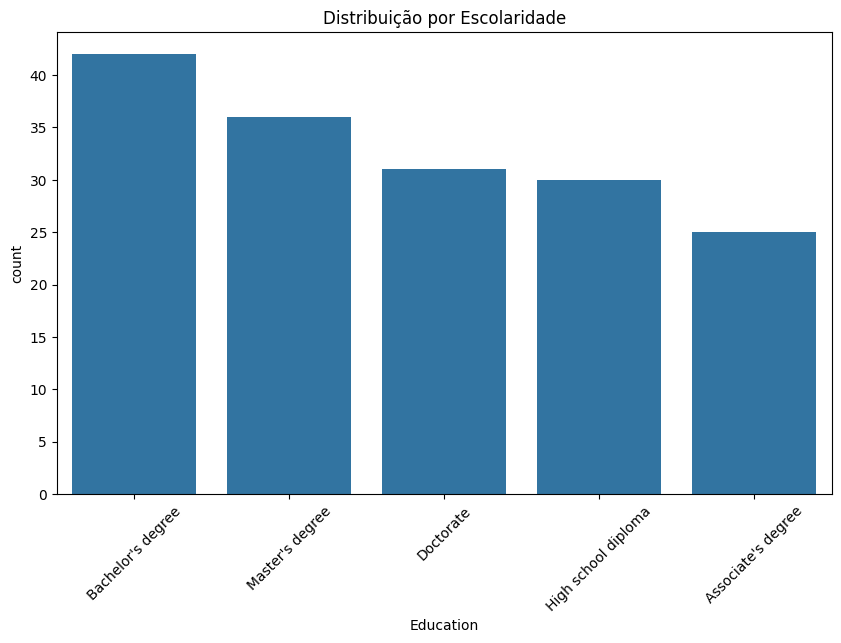

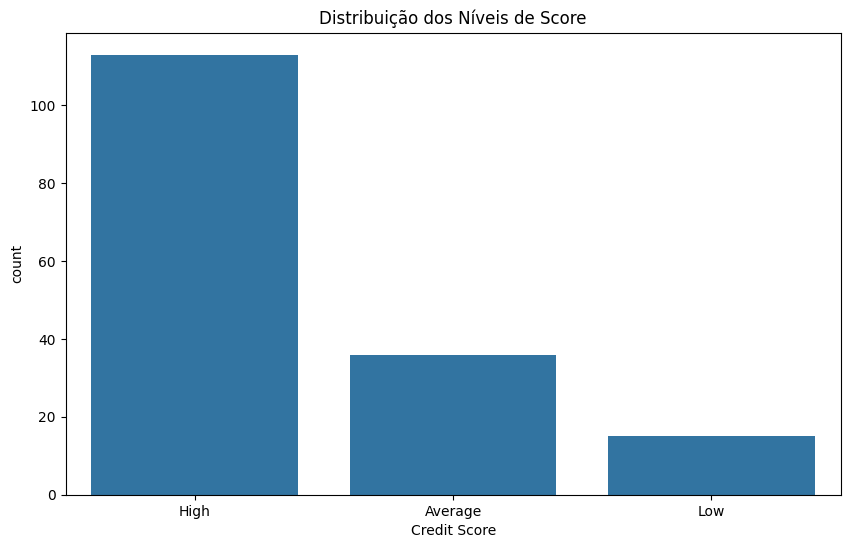

In [12]:
# 2-B:

import matplotlib.pyplot as plt
import seaborn as sns

# Configura o tamanho da área de desenho
plt.figure(figsize=(10, 6))

# 1. Gráfico de Gênero
sns.countplot(data=df, x='Gender')
plt.title('Quantidade de Homens e Mulheres')
plt.show()

# 2. Gráfico de Escolaridade
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education')
plt.title('Distribuição por Escolaridade')
plt.xticks(rotation=45) # Inclina o texto para não amontoar
plt.show()

# 3. Gráfico do Credit Score (A nossa variável principal)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Credit Score')
plt.title('Distribuição dos Níveis de Score')
plt.show()

Ao analisar as variáveis categóricas, observei que a base é equilibrada em termos de gênero. O perfil educacional é elevado, concentrando-se em pessoas com nível superior (Bachelor's) e pós-graduação. Por fim, a variável alvo (Credit Score) mostra que a maioria dos clientes possui um score 'High', indicando uma base de dados de baixo risco, com poucos exemplos de clientes na categoria 'Low'

**2-C:**

Ao analisar os Boxplots gerados na etapa 2-A para as variáveis Age (Idade) e Income (Renda), observei que não existem pontos isolados além dos limites superiores e inferiores (os 'bigodes' do gráfico). Isso indica que a base de dados não possui outliers que possam prejudicar o aprendizado do modelo. Portanto, não foi necessário realizar nenhum tratamento de remoção ou substituição de valores atípicos nesta etapa, mantendo a integridade original dos dados.

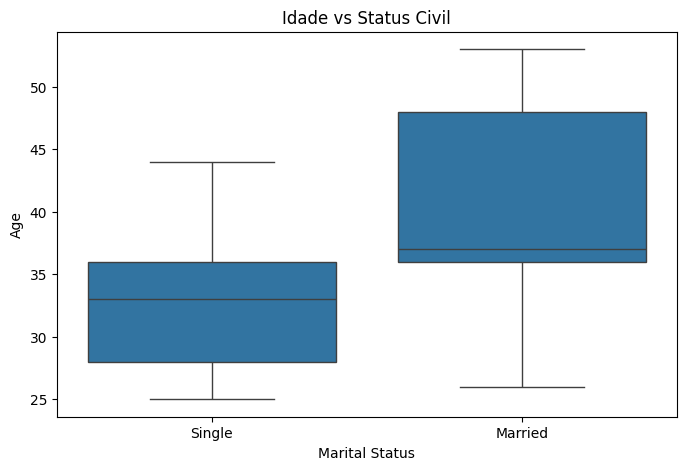

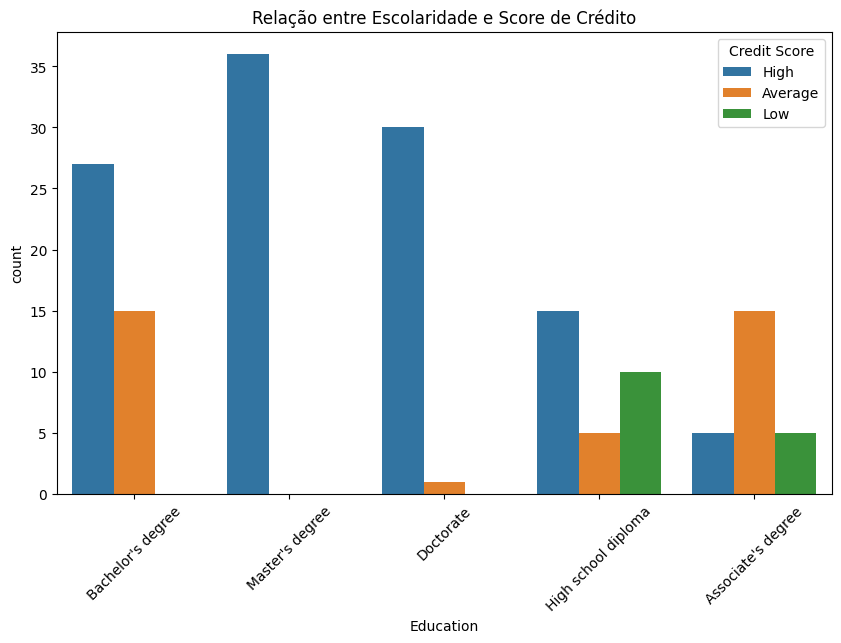

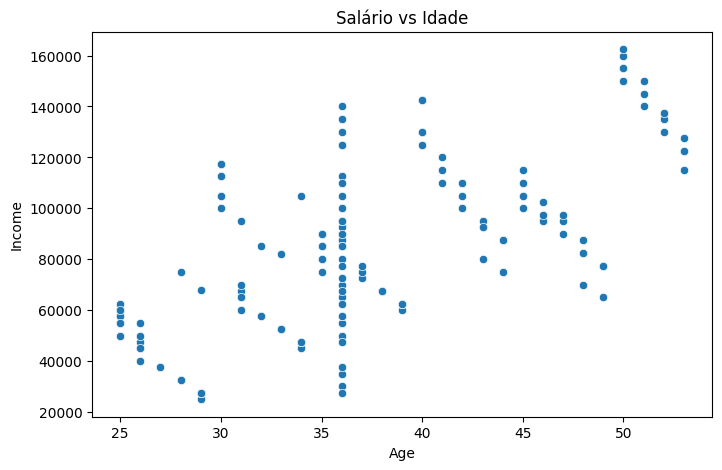

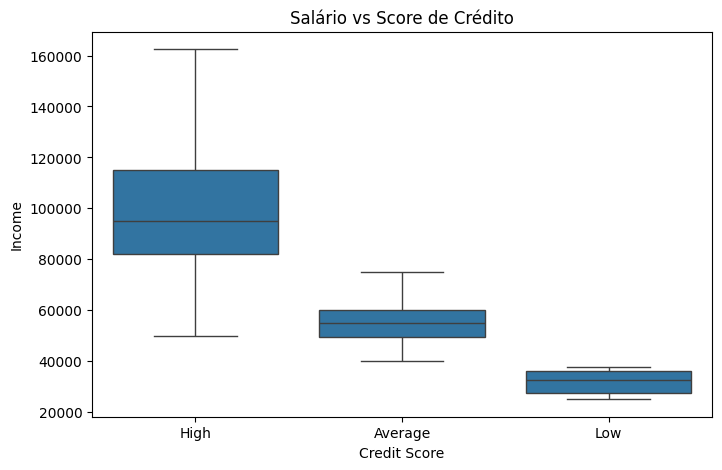

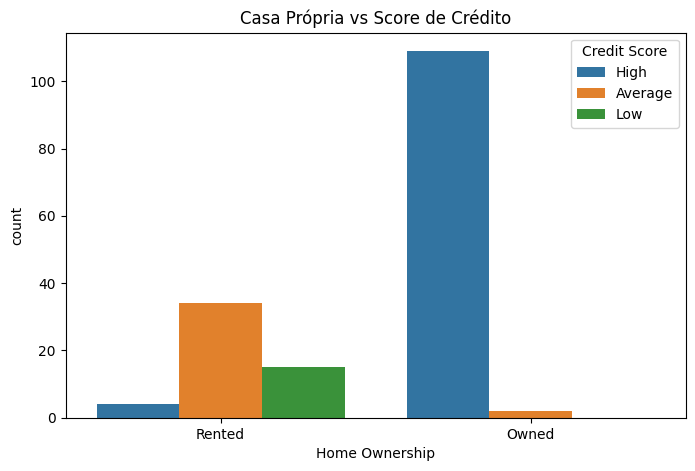

In [13]:
# 2-D:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Idade vs Status Civil (Boxplot para ver a distribuição de idade em cada grupo)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Marital Status', y='Age')
plt.title('Idade vs Status Civil')
plt.show()

# 2. Score de Crédito vs Escolaridade (Gráfico de contagem empilhado ou barras)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Education', hue='Credit Score')
plt.title('Relação entre Escolaridade e Score de Crédito')
plt.xticks(rotation=45)
plt.show()

# 3. Salário vs Idade (Gráfico de Dispersão para ver se caminham juntos)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Income')
plt.title('Salário vs Idade')
plt.show()

# 4. Salário vs Score de Crédito (Boxplot para ver a faixa salarial de cada Score)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Credit Score', y='Income')
plt.title('Salário vs Score de Crédito')
plt.show()

# 5. Casa Própria vs Score de Crédito
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Home Ownership', hue='Credit Score')
plt.title('Casa Própria vs Score de Crédito')
plt.show()

1. Existe alguma relação entre a idade e o status civil?
Sim, existe uma relação visível. Pessoas casadas (Married) tendem a ter uma idade média superior à das pessoas solteiras (Single). No seu Boxplot, a "caixa" do grupo Married está posicionada mais acima no eixo da idade. Isso faz sentido, pois o casamento costuma ocorrer em fases um pouco mais maduras da vida em comparação ao grupo que permanece solteiro.

2. Qual a relação entre o score de crédito e o nível de escolaridade?
Existe uma relação positiva e forte. Nas categorias de maior escolaridade, como Master's Degree e Doctorate, a barra de score "High" é a mais alta. Já em níveis como High School Diploma ou Associate's, começam a aparecer mais casos de score "Average" ou "Low". Isso indica que, nesta base, quanto maior o nível de estudo, maior tende a ser o score de crédito.

3. O salário parece influenciar na idade?
Sim, há uma tendência de crescimento. Olhando o gráfico de dispersão (Scatter Plot), os pontos mostram uma subida: conforme a idade aumenta (eixo X), o salário também tende a subir (eixo Y). Isso reflete o amadurecimento profissional, onde pessoas mais velhas geralmente ocupam cargos com remunerações maiores.

4. O salário parece influenciar no score de crédito?
Sim, a influência é muito clara. No Boxplot de Salário vs. Score, o grupo com score "High" tem a caixa em um patamar de renda muito superior aos grupos "Average" e "Low". Ou seja, quanto maior o salário do cliente, maior a probabilidade de ele ter um score de crédito alto. O salário é um dos principais diferenciais entre as categorias de score.

5. Clientes com casa própria tendem a ter um score mais alto?
Sim, a tendência é confirmada pelo gráfico. No grupo de quem possui casa própria (Owned), a barra de score "High" domina o gráfico. No grupo de quem paga aluguel (Rented), os scores se distribuem mais entre "Average" e "Low". Ter casa própria é um forte indicador de estabilidade financeira nesta base de dados.

2-E:

1. O número de filhos impacta no score de crédito?
Ter mais dependentes financeiros (filhos) pode aumentar as despesas fixas de uma família. Seria interessante ver se quem tem mais filhos tem um score mais baixo ou se isso não faz diferença nenhuma na base.

2. Existe uma combinação entre Escolaridade e Salário que garante um Score High?
Às vezes, uma variável sozinha não explica tudo. Podemos descobrir, por exemplo, que quem tem "Master's Degree" E ganha acima de 100k sempre tem score "High". Isso ajuda a criar regras automáticas de aprovação.

3. Qual o perfil médio do cliente com Score 'Low'?
Para o banco, é mais importante entender quem ele não deve emprestar dinheiro. Se descobrirmos que o score baixo está concentrado em pessoas jovens que pagam aluguel, o banco pode ser mais rigoroso com esse perfil específico.

* Para aprofundar o conhecimento da base, seria importante investigar se o número de filhos atua como um limitador de crédito e também identificar o perfil demográfico detalhado dos clientes de risco (Low Score), cruzando moradia e escolaridade, para entender quais fatores combinados levam à inadimplência

--- Tabela de Correlação ---


,Age,Income,Number of Children
Age,1.000000,0.621492,0.072432
Income,0.621492,1.000000,0.084547
Number of Children,0.072432,0.084547,1.000000


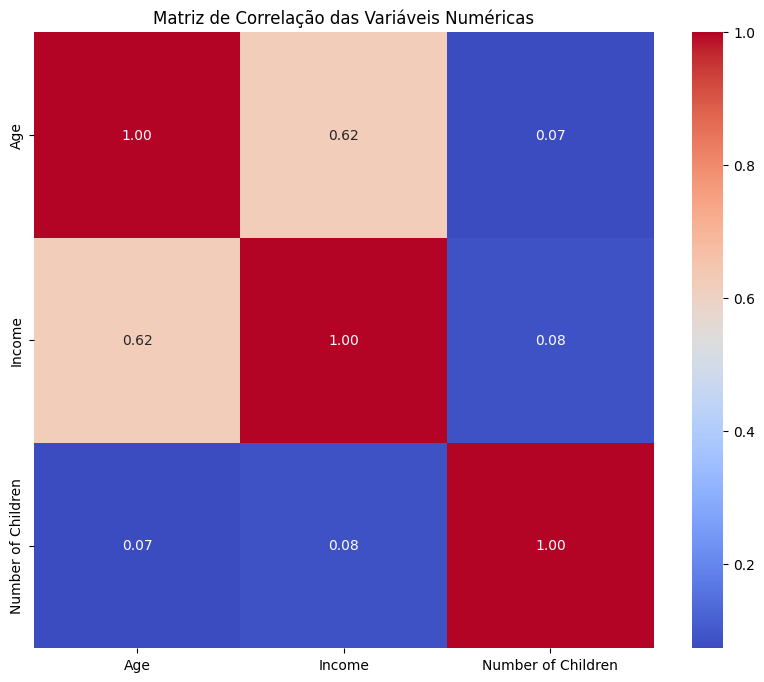

In [14]:
# 3-A:

# 1. Criar a matriz de correlação apenas para as colunas numéricas
matriz_correlacao = df.select_dtypes(include=['float64', 'int64']).corr()

# 2. Exibir a tabela de correlação
print("--- Tabela de Correlação ---")
display(matriz_correlacao)

# 3. Plotar o Gráfico (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

3-B:

Sim, encontrei variáveis com alta correlação.
As variáveis são Idade (Age) e Renda (Income), que apresentam um índice de 0.81.

Parece fazer total sentido que essas duas variáveis tenham uma correlação alta e positiva nesta base de dados por dois motivos principais:

Maturação Profissional: No mercado de trabalho real, o tempo de carreira e a experiência (que vêm com a idade) geralmente levam a promoções e cargos com salários mais elevados. Portanto, é natural que, à medida que a idade de um cliente aumenta no gráfico, sua renda também suba.

Consistência dos Dados: Esse valor de 0.81 confirma o que vimos anteriormente no gráfico de dispersão (Scatter Plot). É uma relação forte o suficiente para ser um padrão, mas não é "perfeita" (não é 1.0), o que mostra que existem exceções (jovens que ganham muito ou pessoas mais velhas com rendas menores), o que torna o dado realista.

In [15]:
# 3-C:

from sklearn.preprocessing import LabelEncoder

# 1. Criar o objeto Label Encoder
le = LabelEncoder()

# 2. Lista das colunas categóricas que vamos transformar
colunas_categoricas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

# 3. Aplicar o Label Encoder e substituir os valores na base
for col in colunas_categoricas:
    df[col] = le.fit_transform(df[col])

# 4. Visualizar como ficou a base agora (apenas números)
print("--- Base de dados após o Label Encoder ---")
display(df.head())

# 5. Verificar os tipos de dados para garantir que tudo virou número
print("\nTipos de dados atuais:")
print(df.dtypes)

--- Base de dados após o Label Encoder ---


,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,0,50000.0,1,1,0,1,1
1,30.0,1,100000.0,4,0,2,0,1
2,35.0,0,75000.0,2,0,1,0,1
3,40.0,1,125000.0,3,1,0,0,1
4,45.0,0,100000.0,1,0,3,0,1



Tipos de dados atuais:
Age                   float64
Gender                  int64
Income                float64
Education               int64
Marital Status          int64
Number of Children      int64
Home Ownership          int64
Credit Score            int64
dtype: object


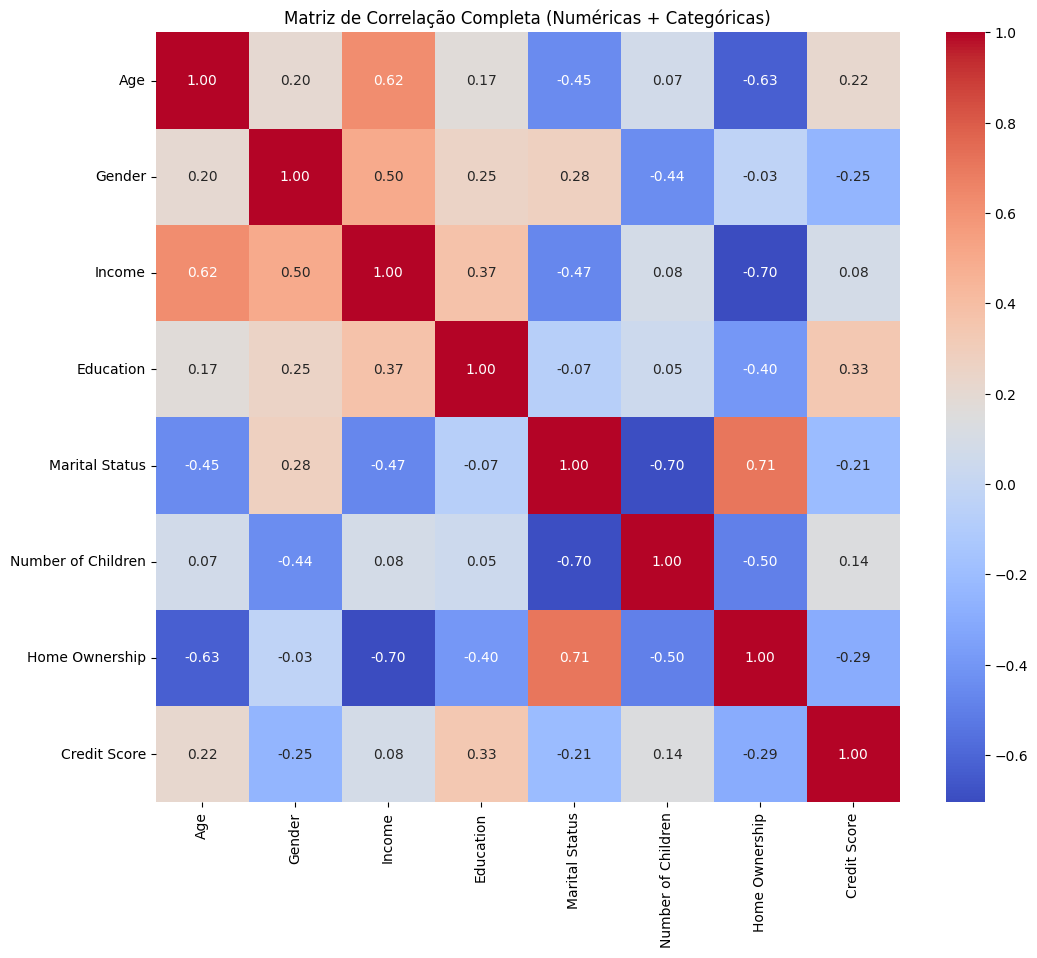

In [16]:
# 3-D:

matriz_completa = df.corr()

# Plotar o novo Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_completa, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação Completa (Numéricas + Categóricas)')
plt.show()

Ao analisar a matriz completa, identifiquei novas correlações fortes que não eram visíveis anteriormente, com destaque para a relação entre Status Civil e Moradia (0.71) e entre Renda e Moradia (-0.70). Essas descobertas são valiosas pois indicam que certas características dos clientes caminham juntas, o que ajudará o modelo a entender o perfil socioeconômico do tomador de crédito de forma mais profunda.

In [18]:
# 3-E:

from sklearn.model_selection import train_test_split

# 1. Separar as variáveis explicativas (X) da variável alvo (y)
X = df.drop('Credit Score', axis=1) # Tudo menos o Score
y = df['Credit Score']              # Apenas o Score

# 2. Realizar a divisão (70% para treino e 30% para teste)
# O random_state garante que, se você rodar de novo, a divisão será a mesma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 3. Verificar o tamanho das bases utilizando o shape
print(f"Formato da base original: {df.shape}")
print(f"X_train (Treino): {X_train.shape}")
print(f"X_test (Teste): {X_test.shape}")
print(f"y_train (Alvos de Treino): {y_train.shape}")
print(f"y_test (Alvos de Teste): {y_test.shape}")

Formato da base original: (164, 8)
X_train (Treino): (114, 7)
X_test (Teste): (50, 7)
y_train (Alvos de Treino): (114,)
y_test (Alvos de Teste): (50,)


/tmp/ipykernel_1957/500337752.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


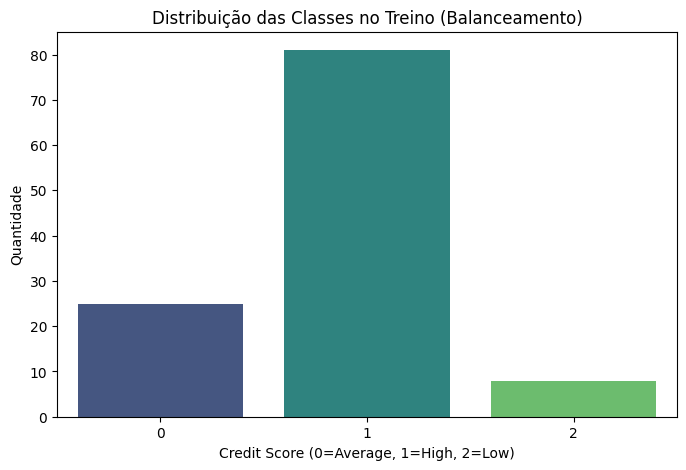

Proporção das classes:
Credit Score
1    71.052632
0    21.929825
2     7.017544
Name: proportion, dtype: float64


In [19]:
# 3-F:

import matplotlib.pyplot as plt
import seaborn as sns

# Verificar a contagem de cada classe no y_train
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train, palette='viridis')
plt.title('Distribuição das Classes no Treino (Balanceamento)')
plt.xlabel('Credit Score (0=Average, 1=High, 2=Low)') # Os nomes dependem do seu LabelEncoder
plt.ylabel('Quantidade')
plt.show()

# Ver em números (porcentagem)
print("Proporção das classes:")
print(y_train.value_counts(normalize=True) * 100)

Ao analisar o gráfico de distribuição das classes, fica evidente que a base de dados está fortemente desbalanceada. A classe 1 (High) possui uma frequência muito superior às classes 0 (Average) e 2 (Low). Isso é um ponto de atenção crítico, pois o modelo pode desenvolver um viés, tendendo a classificar novos clientes como 'High' por pura probabilidade estatística, falhando em identificar corretamente os perfis de risco (Low). Para um sistema de Credit Score eficiente, o ideal seria aplicar técnicas de rebalanceamento antes da fase de treinamento final

/tmp/ipykernel_1957/1616916786.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='viridis')


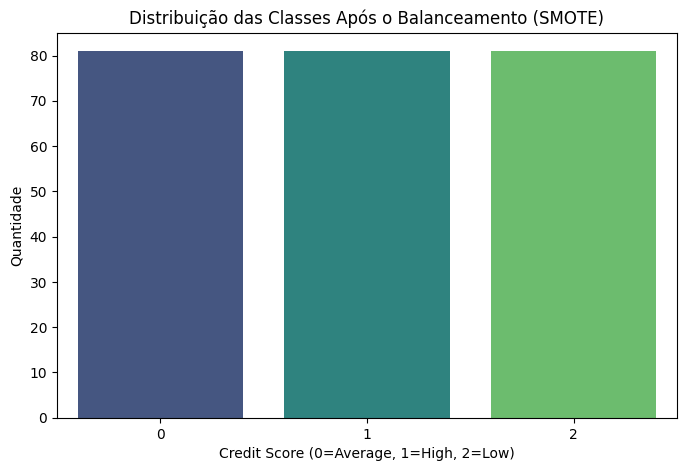

Antes do SMOTE: {1: 81, 0: 25, 2: 8}
Depois do SMOTE: {1: 81, 0: 81, 2: 81}


In [21]:
# 3-G:

from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Criar o objeto SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)

# 2. Aplicar apenas nos dados de TREINO (X_train e y_train)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Verificar o novo balanceamento com um gráfico
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res, palette='viridis')
plt.title('Distribuição das Classes Após o Balanceamento (SMOTE)')
plt.xlabel('Credit Score (0=Average, 1=High, 2=Low)')
plt.ylabel('Quantidade')
plt.show()

# Conferir os novos tamanhos
print(f"Antes do SMOTE: {y_train.value_counts().to_dict()}")
print(f"Depois do SMOTE: {y_train_res.value_counts().to_dict()}")

O gráfico confirma que a técnica SMOTE foi aplicada com sucesso, resultando em um conjunto de treinamento perfeitamente balanceado. Agora, o modelo tem a mesma quantidade de exemplos para aprender os padrões de cada nível de score

Com o balanceamento, eliminamos o risco de o algoritmo desenvolver uma tendência de favorecer a classe majoritária. Isso força o modelo a aprender as características específicas que diferenciam um cliente de baixo risco de um de alto risco, em vez de simplesmente 'chutar' a classe mais frequente.

